# 🌡️ Bolivia: Predicción de Temperatura Media por Ciudades (2026–2030)
### + Predicción Temperatura Diaria El Alto — Junio 2026

**Autor:** Karen Chuquimia  
**Institución:** Universidad — Ciencia de Datos  
**Fecha:** Mayo 2026  

---

## 📋 Descripción del Proyecto

Este notebook realiza:

1. **Análisis exploratorio** de temperaturas históricas 1990–2026 de 10 ciudades de Bolivia  
2. **Predicción mensual 2026–2030** usando modelos SARIMA por ciudad  
3. **Predicción diaria Junio 2026** para la ciudad de El Alto usando datos diarios (Ene–May 2026)  
4. **Exportación de datos** en formato CSV para visualización en Tableau  

**Ciudades:** Sucre, La Paz, Cochabamba, Oruro, Potosí, Tarija, Santa Cruz, Trinidad, Cobija, El Alto  
**Fuente:** SENAMHI – Servicio Nacional de Meteorología e Hidrología de Bolivia


## 1. Instalación de librerías

In [1]:
# Instalar librerías necesarias (ejecutar una vez)
# !pip install prophet statsmodels scikit-learn matplotlib seaborn openpyxl nbformat

import warnings
warnings.filterwarnings('ignore')
print("✓ Librerías listas")


✓ Librerías listas


## 2. Importación de librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import re
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from IPython.display import display

# Configuración de estilo
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (14, 5), 
                     'font.size': 11, 'axes.titlesize': 13})

COLORES_CIUDADES = {
    'SUCRE': '#E74C3C', 'LA PAZ': '#3498DB', 'COCHABAMBA': '#2ECC71',
    'ORURO': '#9B59B6', 'POTOSÍ': '#F39C12', 'TARIJA': '#1ABC9C',
    'SANTA CRUZ': '#E67E22', 'TRINIDAD': '#E91E63', 'COBIJA': '#00BCD4',
    'EL ALTO': '#795548'
}

print("✓ Importaciones completadas")


✓ Importaciones completadas


## 3. Carga y Limpieza de Datos Históricos (1990–2026)

Los datos tienen una estructura jerárquica: por cada año se listan los 12 meses. 
El parser extrae cada fila mensual con su año correspondiente.


In [3]:
# Ruta al archivo (ajusta si es necesario)
RUTA_TEMP = "BOLIVIA - TEMPERATURA MEDIA POR CIUDADES, SEGÚN AÑO Y MES, 1990 - 2026.xlsx"
RUTA_DIARIO = "Diario.xlsx"

CIUDADES = ['SUCRE', 'LA PAZ', 'COCHABAMBA', 'ORURO', 'POTOSÍ', 'TARIJA', 
            'SANTA CRUZ', 'TRINIDAD', 'COBIJA', 'EL ALTO']

MESES_ES = ['Enero','Febrero','Marzo','Abril','Mayo','Junio',
            'Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre']
MESES_NUM = {m: i+1 for i, m in enumerate(MESES_ES)}
MESES_MAP = {i+1: m for i, m in enumerate(MESES_ES)}

# Parsear archivo Excel
df_raw = pd.read_excel(RUTA_TEMP, sheet_name='BOLIVIA', header=None)

records = []
current_year = None

for i in range(len(df_raw)):
    val = str(df_raw.iloc[i, 1]).strip()
    match = re.match(r'^(\d{4})', val)
    if match:
        yr = int(match.group(1))
        if 1990 <= yr <= 2030:
            current_year = yr
            continue
    if val in MESES_NUM and current_year is not None:
        row_data = {'year': current_year, 'month': MESES_NUM[val], 'month_name': val}
        for j, city in enumerate(CIUDADES):
            raw_val = df_raw.iloc[i, j+2]
            try:
                row_data[city] = float(raw_val)
            except:
                row_data[city] = np.nan
        records.append(row_data)

df = pd.DataFrame(records)
df['date'] = pd.to_datetime(df[['year','month']].assign(day=1))

print(f"✓ Datos cargados: {df.shape[0]} registros mensuales ({df['year'].min()}–{df['year'].max()})")
print(f"  Ciudades: {len(CIUDADES)}")
print(f"  Valores faltantes por ciudad:")
display(df[CIUDADES].isnull().sum().rename("Faltantes").to_frame().T)


✓ Datos cargados: 436 registros mensuales (1990–2026)
  Ciudades: 10
  Valores faltantes por ciudad:


,SUCRE,LA PAZ,COCHABAMBA,ORURO,POTOSÍ,TARIJA,SANTA CRUZ,TRINIDAD,COBIJA,EL ALTO
Faltantes,6,3,1,3,27,7,1,2,1,0


## 4. Análisis Exploratorio de Datos (EDA)

In [4]:
# 4.1 Estadísticas descriptivas
desc = df[CIUDADES].describe().round(2)
display(desc)


,SUCRE,LA PAZ,COCHABAMBA,ORURO,POTOSÍ,TARIJA,SANTA CRUZ,TRINIDAD,COBIJA,EL ALTO
count,430.00,433.00,435.00,433.00,409.00,429.00,435.00,434.00,435.00,436.00
mean,14.61,12.60,18.15,9.49,8.40,18.32,24.60,25.92,26.14,7.82
std,1.54,1.47,2.17,3.26,2.36,2.95,2.53,1.86,1.39,1.80
min,10.90,7.00,13.00,2.00,0.90,10.60,16.75,19.30,21.15,3.30
25%,13.50,11.60,16.40,6.60,6.70,15.80,22.70,24.70,25.45,6.24
50%,14.70,12.74,18.57,10.50,8.80,19.30,25.55,26.50,26.30,8.30
75%,15.70,13.65,19.80,12.20,10.02,20.69,26.44,27.20,27.00,9.20
max,18.40,15.80,22.68,14.76,13.64,24.00,29.27,30.16,30.27,11.20


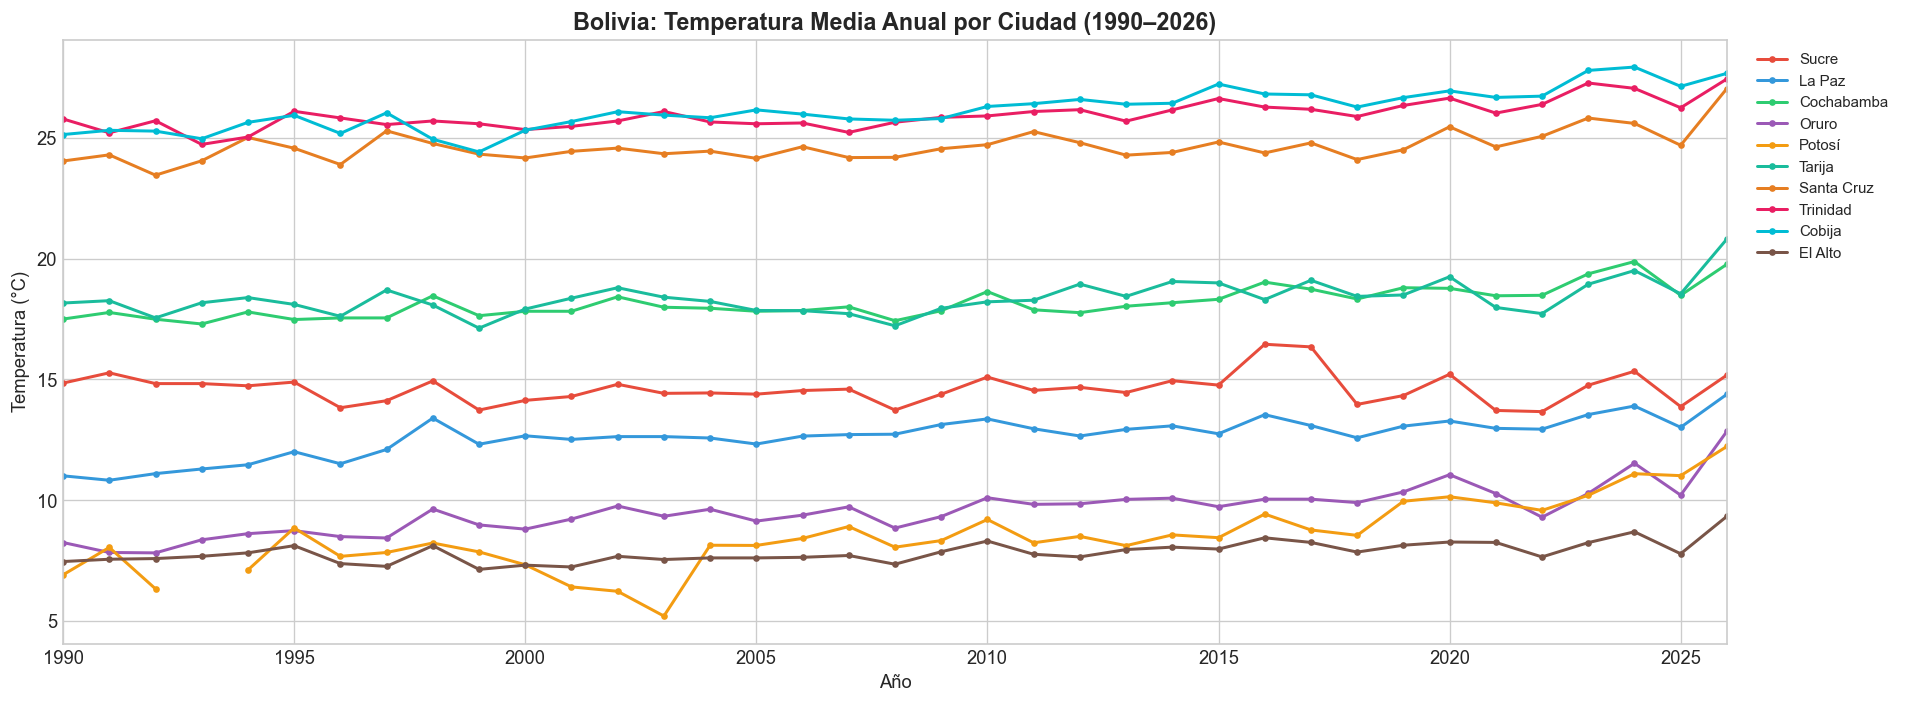

In [5]:
# 4.2 Temperatura media anual por ciudad (1990–2026)
anual = df.groupby('year')[CIUDADES].mean()

fig, ax = plt.subplots(figsize=(16, 6))
for city in CIUDADES:
    ax.plot(anual.index, anual[city], marker='o', markersize=3, 
            label=city.title(), color=COLORES_CIUDADES[city], linewidth=1.8)

ax.set_title('Bolivia: Temperatura Media Anual por Ciudad (1990–2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Temperatura (°C)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.set_xlim(1990, 2026)
plt.tight_layout()
plt.show()


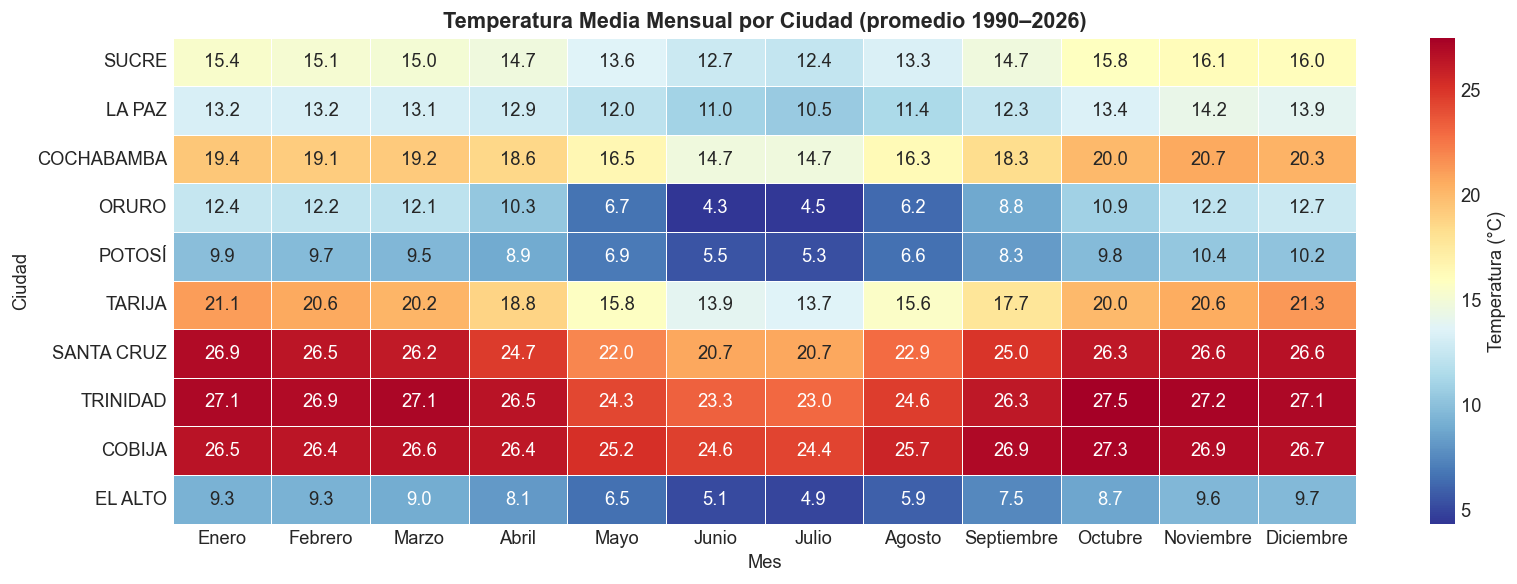

In [6]:
# 4.3 Mapa de calor - Temperatura media mensual por ciudad
pivot = df.groupby('month')[CIUDADES].mean()
pivot.index = MESES_ES

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot.T, cmap='RdYlBu_r', annot=True, fmt='.1f',
            linewidths=0.5, cbar_kws={'label': 'Temperatura (°C)'}, ax=ax)
ax.set_title('Temperatura Media Mensual por Ciudad (promedio 1990–2026)', fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Ciudad')
plt.tight_layout()
plt.show()


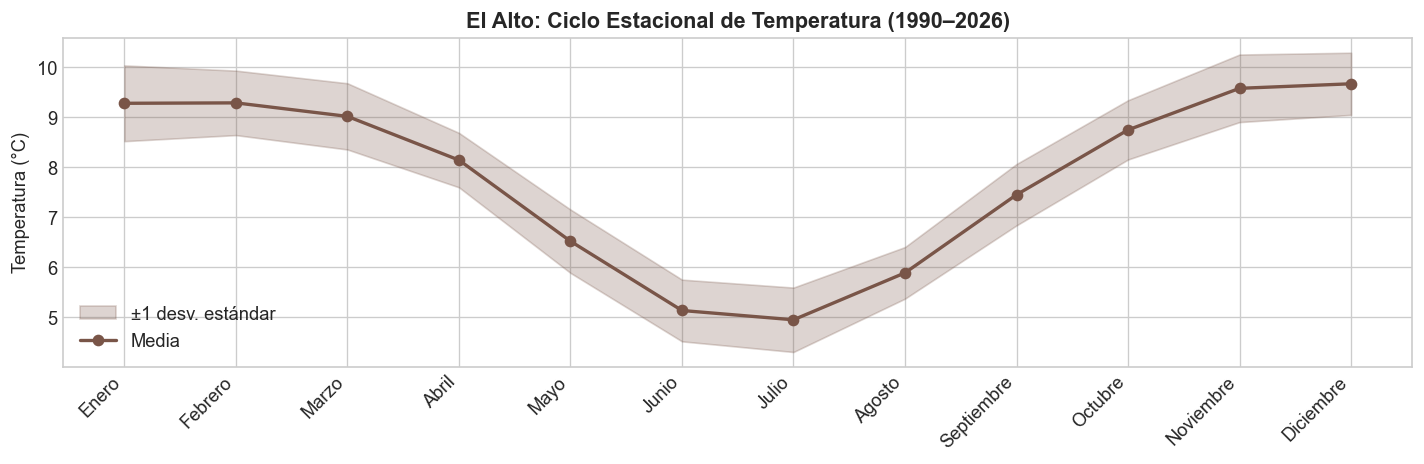

Mes más frío: Julio (4.95°C)
Mes más cálido: Diciembre (9.67°C)


In [7]:
# 4.4 Ciclo estacional de El Alto (ciudad foco)
el_alto_mes = df.groupby('month')['EL ALTO'].agg(['mean','std']).reset_index()
el_alto_mes['mes_name'] = el_alto_mes['month'].map(MESES_MAP)

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(range(12), 
                el_alto_mes['mean'] - el_alto_mes['std'],
                el_alto_mes['mean'] + el_alto_mes['std'],
                alpha=0.25, color='#795548', label='±1 desv. estándar')
ax.plot(range(12), el_alto_mes['mean'], 'o-', color='#795548', linewidth=2, markersize=6, label='Media')
ax.set_xticks(range(12))
ax.set_xticklabels(MESES_ES, rotation=45, ha='right')
ax.set_title('El Alto: Ciclo Estacional de Temperatura (1990–2026)', fontweight='bold')
ax.set_ylabel('Temperatura (°C)')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Mes más frío: {el_alto_mes.loc[el_alto_mes['mean'].idxmin(), 'mes_name']} ({el_alto_mes['mean'].min():.2f}°C)")
print(f"Mes más cálido: {el_alto_mes.loc[el_alto_mes['mean'].idxmax(), 'mes_name']} ({el_alto_mes['mean'].max():.2f}°C)")


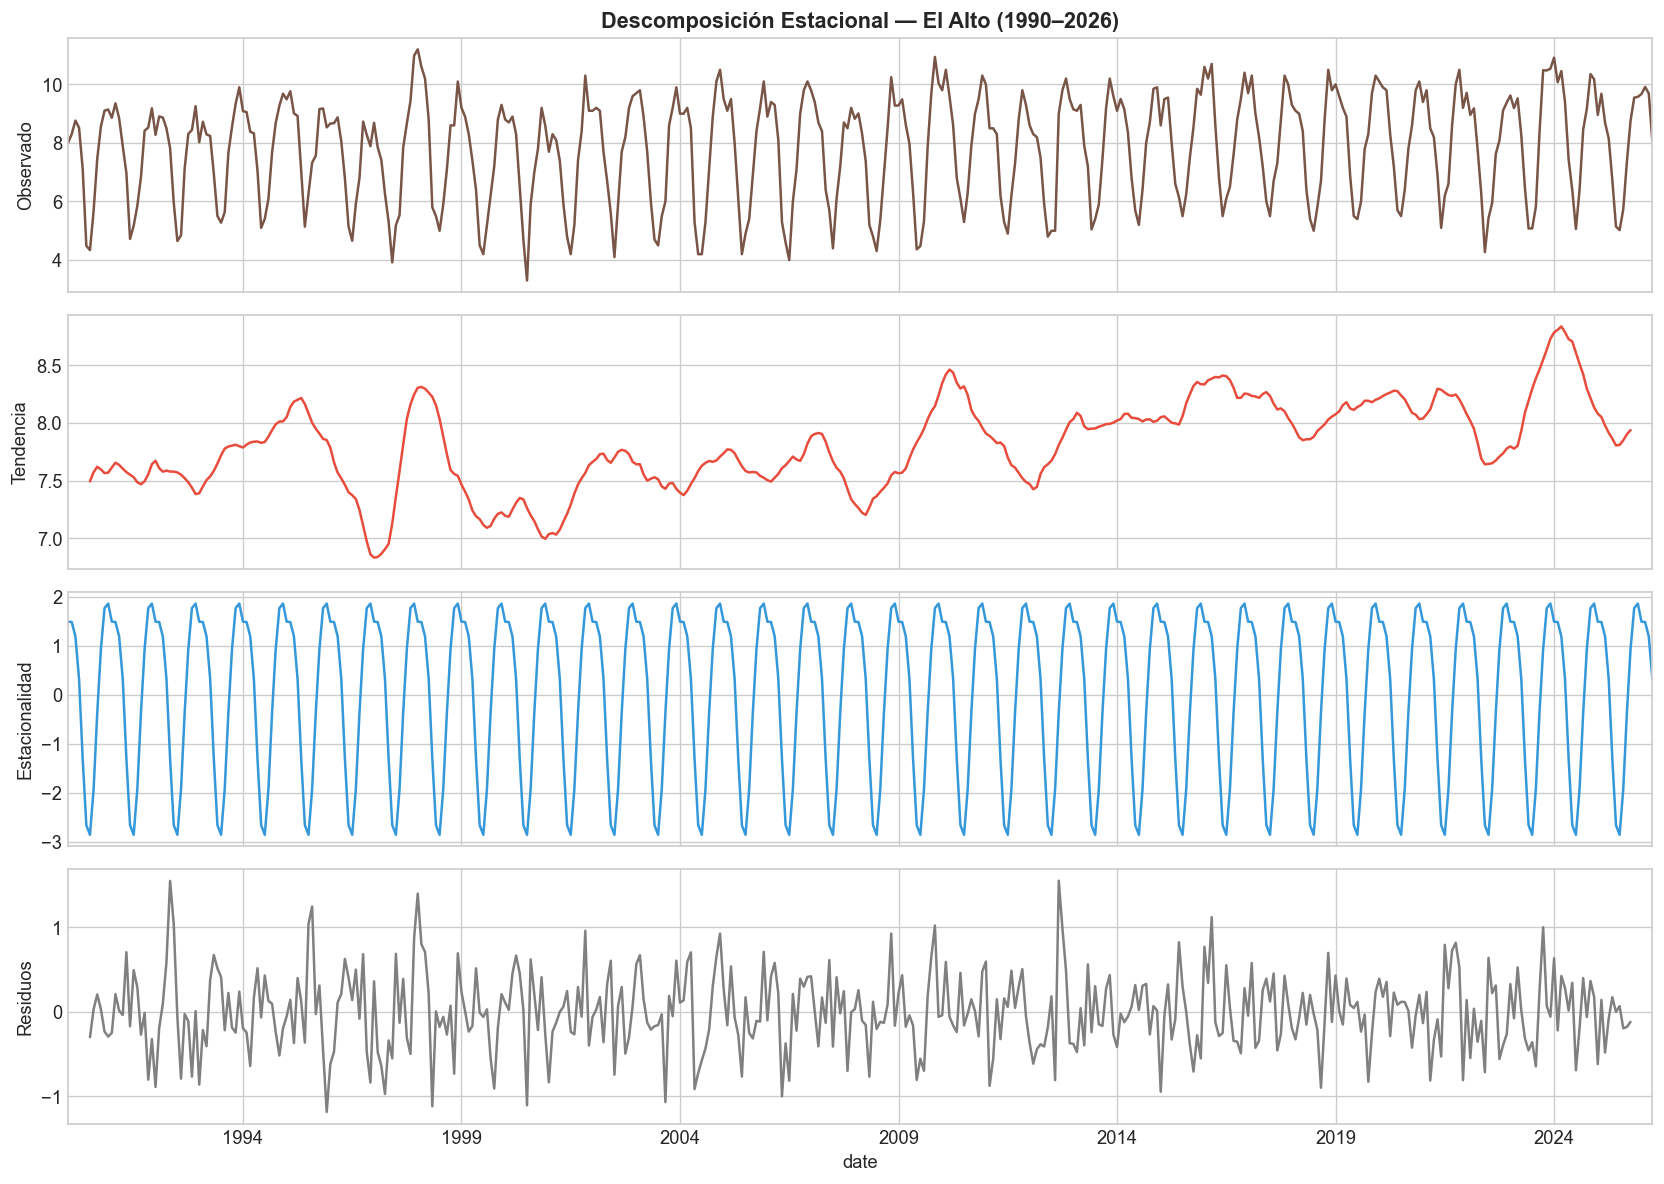

In [8]:
# 4.5 Descomposición estacional - El Alto
ts_elalto = df[['date','EL ALTO']].dropna().set_index('date').sort_index()
ts_elalto.index.freq = 'MS'

decomp = seasonal_decompose(ts_elalto['EL ALTO'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomp.observed.plot(ax=axes[0], color='#795548'); axes[0].set_ylabel('Observado')
decomp.trend.plot(ax=axes[1], color='#E74C3C'); axes[1].set_ylabel('Tendencia')
decomp.seasonal.plot(ax=axes[2], color='#3498DB'); axes[2].set_ylabel('Estacionalidad')
decomp.resid.plot(ax=axes[3], color='gray'); axes[3].set_ylabel('Residuos')
axes[0].set_title('Descomposición Estacional — El Alto (1990–2026)', fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Predicción de Temperatura 2026–2030 (SARIMA)

Se usa el modelo **SARIMA(1,1,1)(1,1,1)[12]** para cada ciudad.
Este modelo captura:
- Tendencia (diferenciación no estacional)
- Estacionalidad mensual (diferenciación estacional de orden 12)
- Autocorrelación de corto y largo plazo


In [9]:
# Función de entrenamiento y predicción SARIMA
def entrenar_sarima(serie, steps=57):
    """Entrena SARIMA y retorna forecasts con intervalos de confianza."""
    idx_full = pd.date_range(serie.index.min(), serie.index.max(), freq='MS')
    serie = serie.reindex(idx_full).interpolate()
    
    model = SARIMAX(serie, order=(1,1,1), seasonal_order=(1,1,1,12),
                    enforce_stationarity=False, enforce_invertibility=False)
    fit = model.fit(disp=False)
    
    forecast = fit.get_forecast(steps=steps)
    return forecast.predicted_mean, forecast.conf_int(), fit

# Entrenar para todas las ciudades
print("Entrenando modelos SARIMA...")
resultados = {}

for city in CIUDADES:
    serie = df[['date', city]].dropna().set_index('date')[city].sort_index()
    last_date = serie.index.max()
    n_steps = (2030 - last_date.year) * 12 + (12 - last_date.month)
    
    fc_mean, fc_ci, fit_model = entrenar_sarima(serie, steps=n_steps)
    resultados[city] = {'mean': fc_mean, 'ci': fc_ci, 'model': fit_model}
    print(f"  ✓ {city:15s} | AIC: {fit_model.aic:.1f} | Pasos: {n_steps}")

print("\n✓ Todos los modelos entrenados!")


Entrenando modelos SARIMA...
  ✓ SUCRE           | AIC: 992.8 | Pasos: 56
  ✓ LA PAZ          | AIC: 880.3 | Pasos: 56
  ✓ COCHABAMBA      | AIC: 881.3 | Pasos: 56
  ✓ ORURO           | AIC: 978.5 | Pasos: 56
  ✓ POTOSÍ          | AIC: 1083.5 | Pasos: 56
  ✓ TARIJA          | AIC: 1289.2 | Pasos: 56
  ✓ SANTA CRUZ      | AIC: 1278.4 | Pasos: 57
  ✓ TRINIDAD        | AIC: 1148.6 | Pasos: 56
  ✓ COBIJA          | AIC: 992.6 | Pasos: 56
  ✓ EL ALTO         | AIC: 671.4 | Pasos: 56

✓ Todos los modelos entrenados!


In [10]:
# Construir DataFrame de predicciones
pred_records = []

for city in CIUDADES:
    fc_mean = resultados[city]['mean']
    fc_ci = resultados[city]['ci']
    
    for date, val, lo, hi in zip(fc_mean.index, fc_mean.values, 
                                  fc_ci.iloc[:,0].values, fc_ci.iloc[:,1].values):
        pred_records.append({
            'ciudad': city, 'fecha': date, 'año': date.year, 'mes': date.month,
            'mes_nombre': MESES_MAP[date.month], 'temperatura': round(val, 4),
            'ci_inferior': round(lo, 4), 'ci_superior': round(hi, 4), 'tipo': 'Predicción'
        })

df_pred = pd.DataFrame(pred_records)
print(f"Predicciones generadas: {df_pred.shape[0]} registros")
print(f"Rango temporal: {df_pred['fecha'].min().strftime('%b %Y')} → {df_pred['fecha'].max().strftime('%b %Y')}")
display(df_pred[df_pred['ciudad']=='EL ALTO'].head(8))


Predicciones generadas: 561 registros
Rango temporal: Apr 2026 → Dec 2030


,ciudad,fecha,año,mes,mes_nombre,temperatura,ci_inferior,ci_superior,tipo
505,EL ALTO,2026-05-01,2026,5,Mayo,6.6476,5.6238,7.6713,Predicción
506,EL ALTO,2026-06-01,2026,6,Junio,5.3958,4.2492,6.5424,Predicción
507,EL ALTO,2026-07-01,2026,7,Julio,5.2786,4.1006,6.4565,Predicción
508,EL ALTO,2026-08-01,2026,8,Agosto,6.2008,5.0134,7.3882,Predicción
509,EL ALTO,2026-09-01,2026,9,Septiembre,7.7965,6.6055,8.9874,Predicción
510,EL ALTO,2026-10-01,2026,10,Octubre,9.1004,7.9078,10.2930,Predicción
511,EL ALTO,2026-11-01,2026,11,Noviembre,9.9624,8.7687,11.1560,Predicción
512,EL ALTO,2026-12-01,2026,12,Diciembre,10.0192,8.8248,11.2135,Predicción


## 6. Visualización de Predicciones 2026–2030

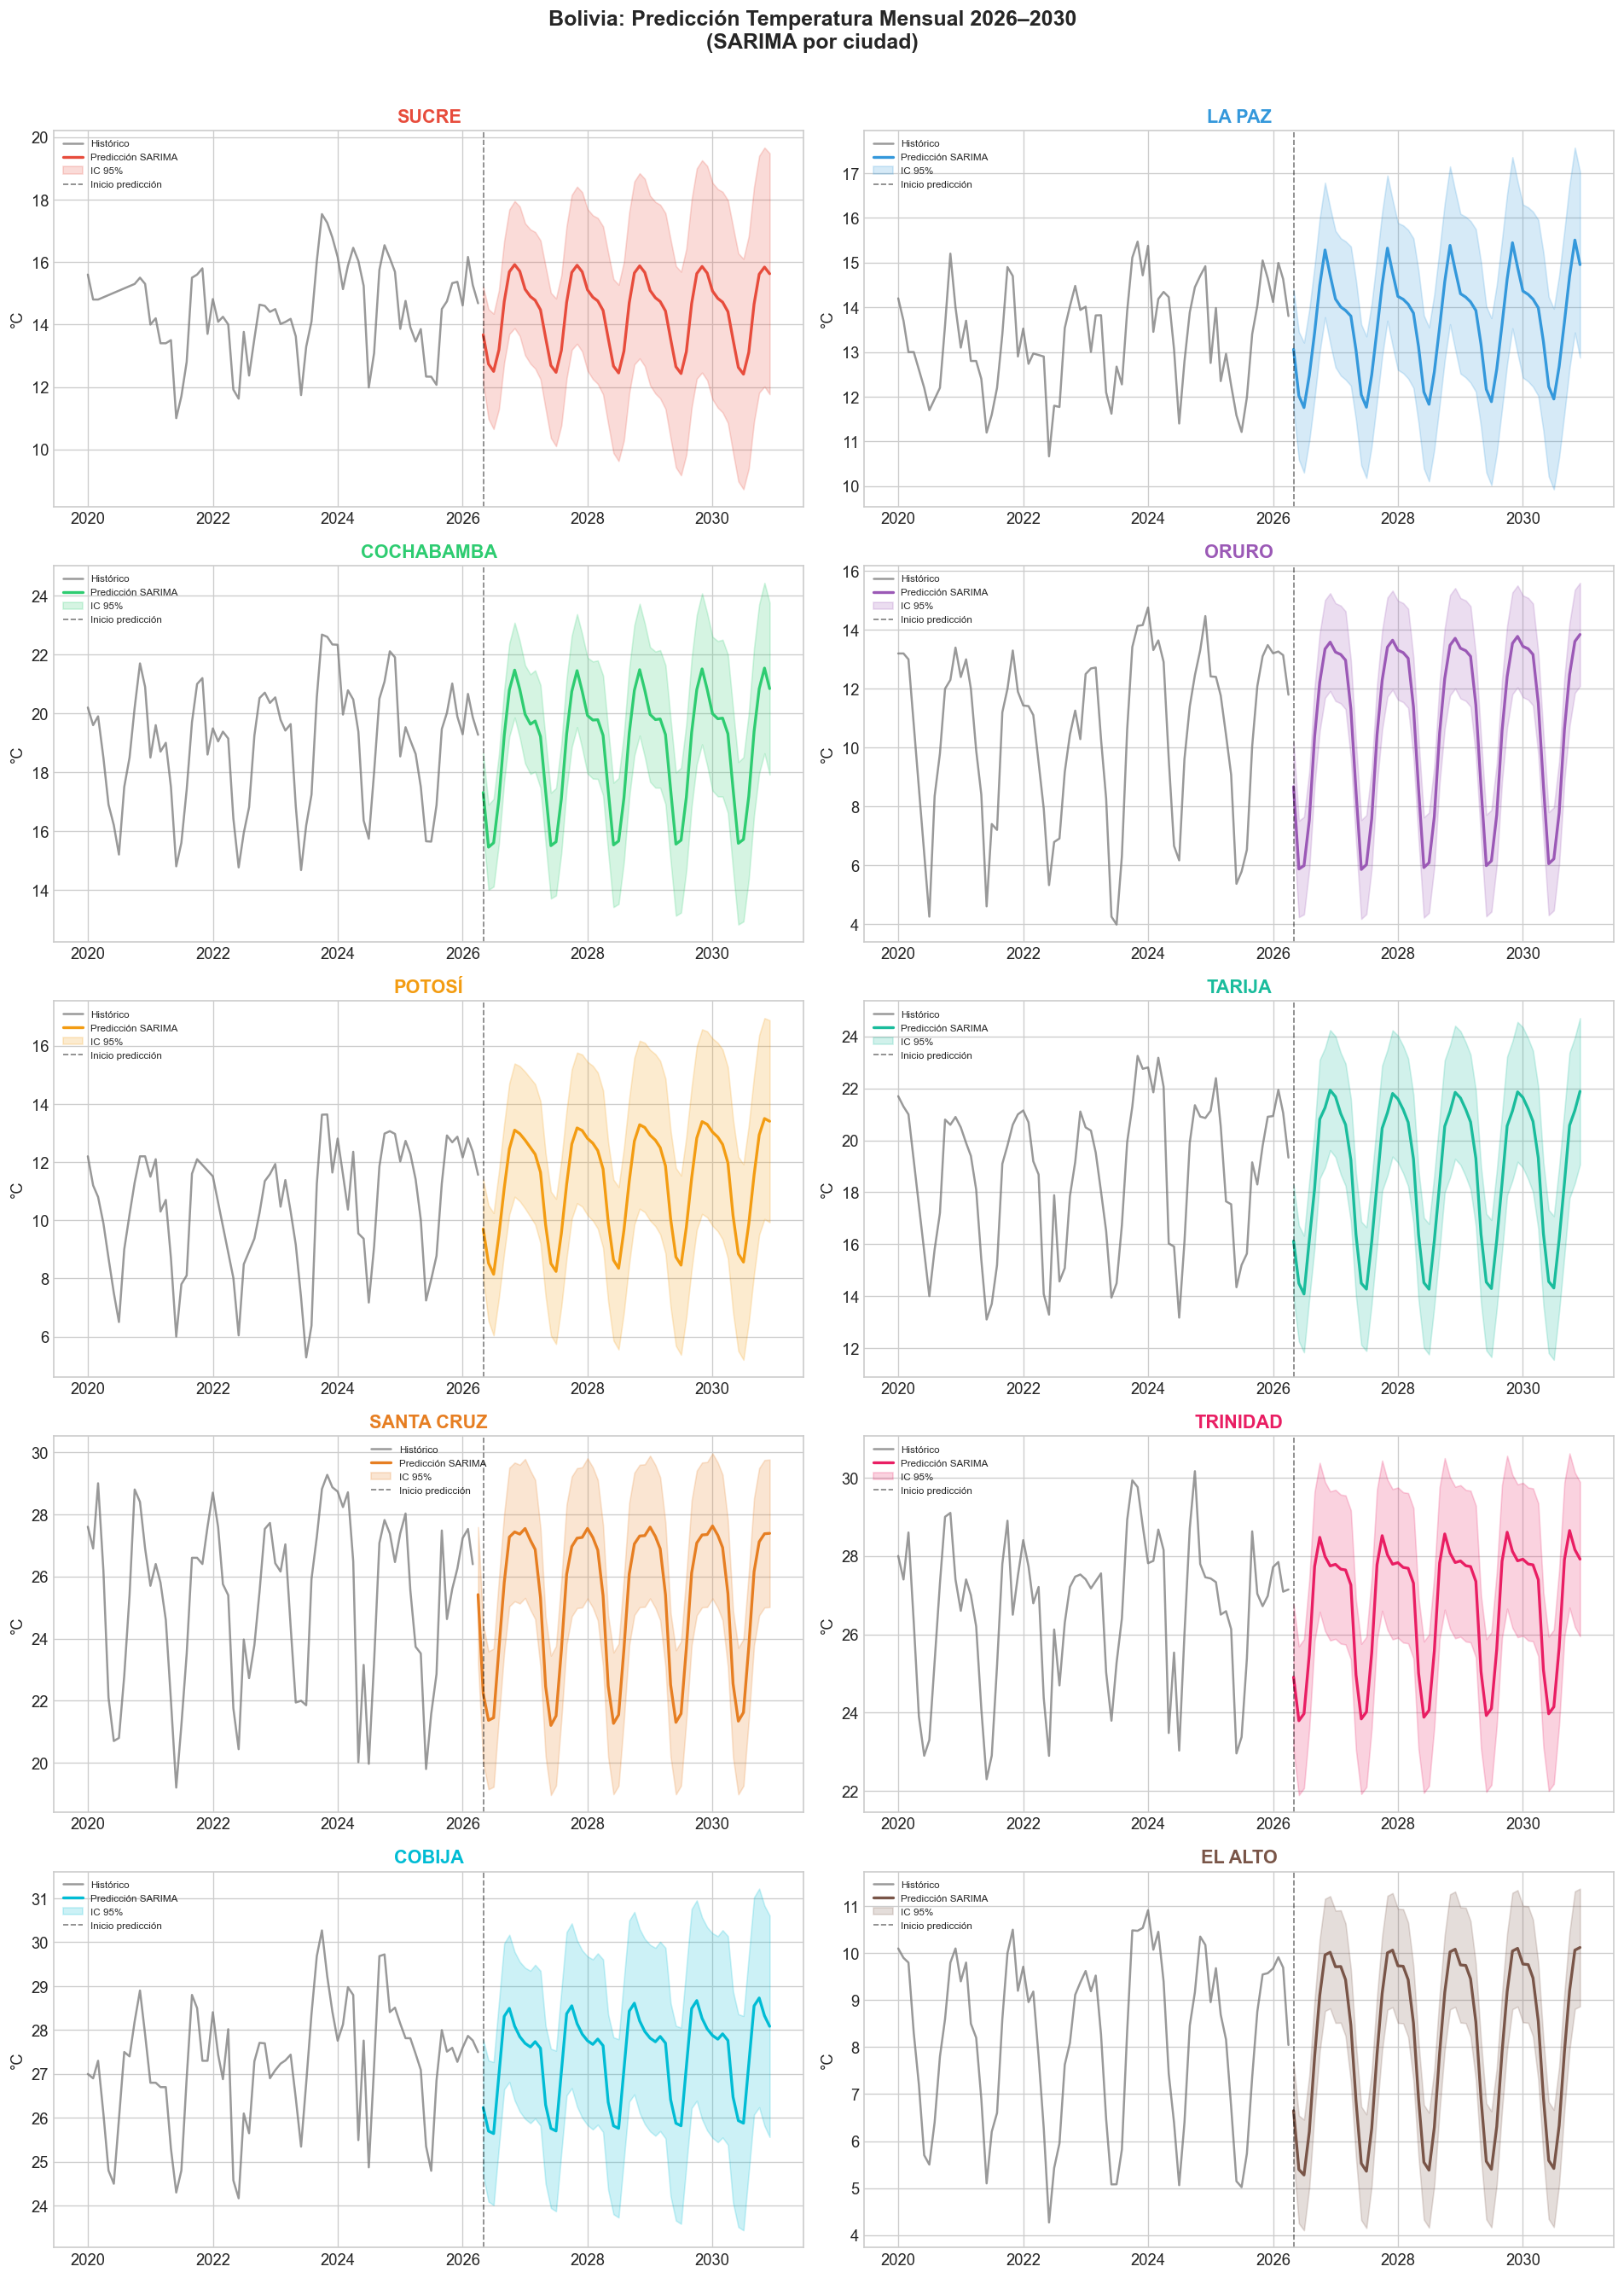

In [11]:
# 6.1 Predicción para todas las ciudades (subplots)
fig, axes = plt.subplots(5, 2, figsize=(16, 22))
axes = axes.flatten()

for idx, city in enumerate(CIUDADES):
    ax = axes[idx]
    color = COLORES_CIUDADES[city]
    
    # Histórico (últimos 5 años)
    hist = df[df['year'] >= 2020][['date', city]].dropna()
    ax.plot(hist['date'], hist[city], color='gray', linewidth=1.5, 
            label='Histórico', alpha=0.8)
    
    # Predicción
    pred_city = df_pred[df_pred['ciudad'] == city]
    ax.plot(pred_city['fecha'], pred_city['temperatura'], 
            color=color, linewidth=2, label='Predicción SARIMA')
    ax.fill_between(pred_city['fecha'], pred_city['ci_inferior'], 
                    pred_city['ci_superior'], alpha=0.2, color=color, label='IC 95%')
    
    ax.axvline(pd.Timestamp('2026-05-01'), color='black', linestyle='--', 
               linewidth=1, alpha=0.5, label='Inicio predicción')
    ax.set_title(f'{city}', fontweight='bold', color=color)
    ax.set_ylabel('°C')
    ax.legend(fontsize=7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('Bolivia: Predicción Temperatura Mensual 2026–2030\n(SARIMA por ciudad)', 
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


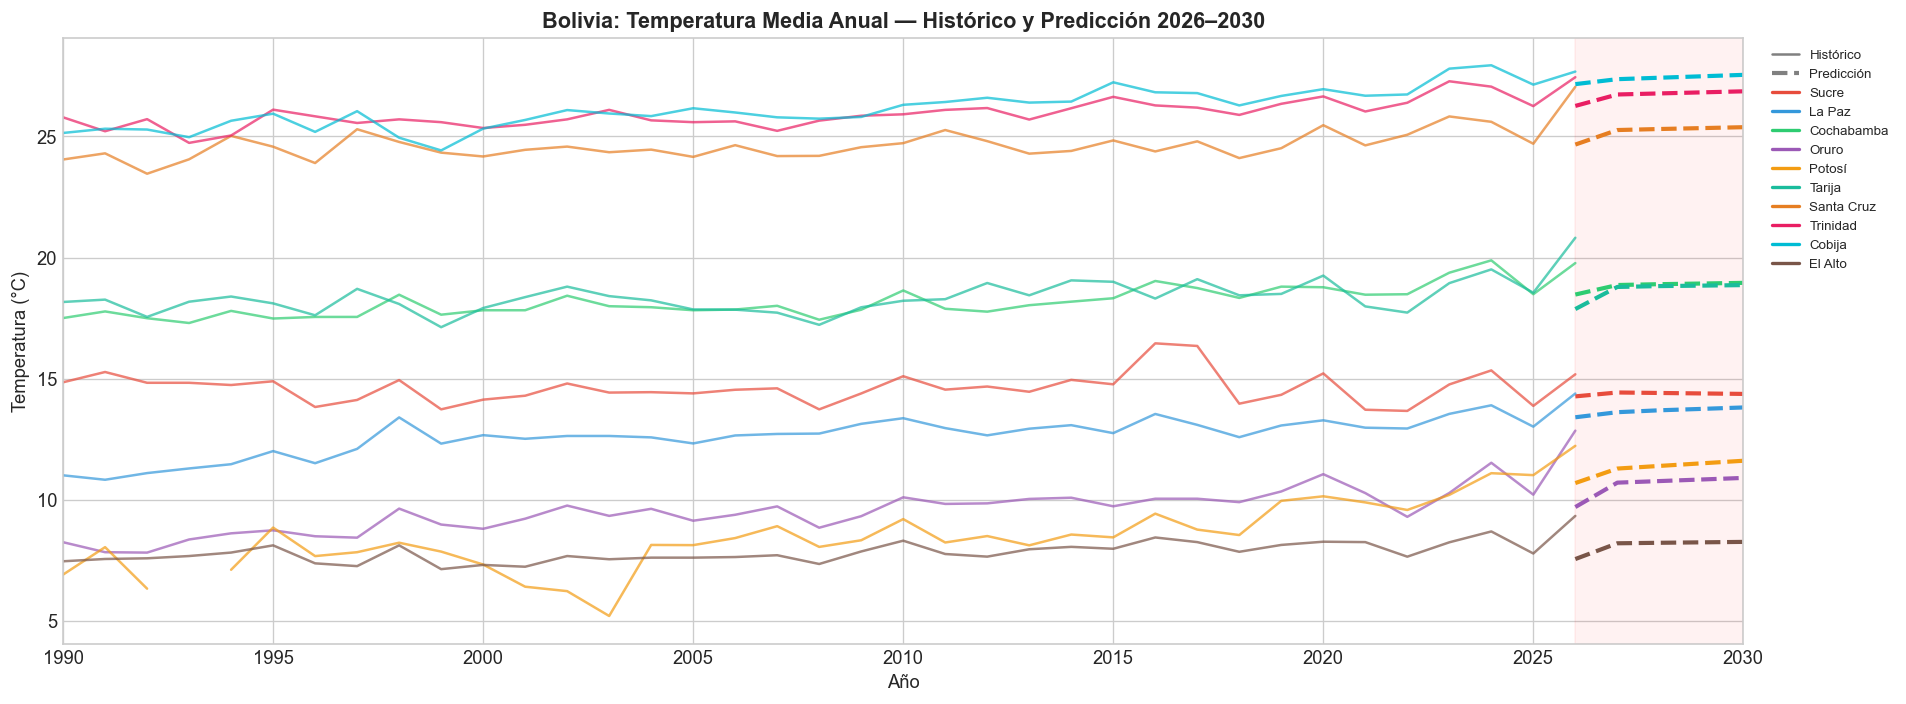

In [12]:
# 6.2 Comparación de temperatura media anual: histórico vs predicción
hist_anual = df.groupby('year')[CIUDADES].mean().reset_index()
pred_anual = df_pred.groupby(['ciudad','año'])['temperatura'].mean().reset_index()
pred_anual.columns = ['ciudad','year','temp']

fig, ax = plt.subplots(figsize=(16, 6))
for city in CIUDADES:
    color = COLORES_CIUDADES[city]
    h = hist_anual[['year', city]].rename(columns={city:'temp'})
    ax.plot(h['year'], h['temp'], color=color, linewidth=1.5, alpha=0.7)
    
    p = pred_anual[pred_anual['ciudad'] == city]
    ax.plot(p['year'], p['temp'], color=color, linewidth=2.5, linestyle='--')

# Leyenda manual
from matplotlib.lines import Line2D
legend_elements = [Line2D([0],[0], color='gray', linewidth=1.5, label='Histórico')]
legend_elements += [Line2D([0],[0], color='gray', linewidth=2.5, linestyle='--', label='Predicción')]
legend_elements += [Line2D([0],[0], color=COLORES_CIUDADES[c], linewidth=2, label=c.title()) for c in CIUDADES]
ax.legend(handles=legend_elements, bbox_to_anchor=(1.01,1), loc='upper left', fontsize=8)
ax.axvspan(2026, 2030, alpha=0.05, color='red', label='Período predicho')
ax.set_title('Bolivia: Temperatura Media Anual — Histórico y Predicción 2026–2030', fontweight='bold')
ax.set_xlabel('Año'); ax.set_ylabel('Temperatura (°C)')
ax.set_xlim(1990, 2030)
plt.tight_layout()
plt.show()


In [13]:
# 6.3 Tabla resumen de predicciones anuales 2026–2030
pred_tabla = df_pred.groupby(['ciudad','año'])['temperatura'].mean().unstack('año').round(2)
pred_tabla.columns.name = None
print("📊 Temperatura Media Anual Predicha por Ciudad (°C):")
display(pred_tabla.style.background_gradient(cmap='RdYlBu_r', axis=None))


📊 Temperatura Media Anual Predicha por Ciudad (°C):


,2026,2027,2028,2029,2030
ciudad,,,,,
COBIJA,27.160000,27.370000,27.430000,27.490000,27.550000
COCHABAMBA,18.470000,18.870000,18.900000,18.930000,18.960000
EL ALTO,7.550000,8.200000,8.220000,8.240000,8.260000
LA PAZ,13.410000,13.610000,13.690000,13.750000,13.810000
ORURO,9.700000,10.710000,10.770000,10.840000,10.900000
POTOSÍ,10.690000,11.290000,11.400000,11.500000,11.610000
SANTA CRUZ,24.670000,25.270000,25.310000,25.350000,25.380000
SUCRE,14.270000,14.430000,14.410000,14.390000,14.370000
TARIJA,17.870000,18.790000,18.820000,18.840000,18.860000


## 7. Predicción Diaria — El Alto: Junio 2026

Se utilizan los datos diarios de Enero a Mayo 2026 para predecir cada día de Junio 2026.  
**Modelo:** Gradient Boosting Regressor + corrección estacional histórica  
**Variables:** día del mes, número de mes, precipitación, tendencia temporal


In [14]:
# Cargar datos diarios
df_diario = pd.read_excel(RUTA_DIARIO)
df_diario['Temp_Media'] = (df_diario['Temp_Max'] + df_diario['Temp_Min']) / 2
df_diario['mes_num'] = df_diario['Fecha'].dt.month
df_diario['dia_mes'] = df_diario['Fecha'].dt.day
df_diario['tendencia'] = range(len(df_diario))

print(f"Datos diarios cargados: {df_diario.shape[0]} días ({df_diario['Fecha'].min().date()} → {df_diario['Fecha'].max().date()})")
print(f"Meses disponibles: {df_diario['Mes'].unique().tolist()}")
display(df_diario[['Fecha','Mes','Temp_Max','Temp_Min','Temp_Media','Precipitación_mm']].head(10))


Datos diarios cargados: 151 días (2026-01-01 → 2026-05-31)
Meses disponibles: ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo']


,Fecha,Mes,Temp_Max,Temp_Min,Temp_Media,Precipitación_mm
0,2026-01-01,Enero,12,5,8.5,0.0
1,2026-01-02,Enero,10,4,7.0,0.0
2,2026-01-03,Enero,15,4,9.5,0.0
3,2026-01-04,Enero,14,6,10.0,0.0
4,2026-01-05,Enero,15,5,10.0,0.0
5,2026-01-06,Enero,16,6,11.0,0.0
6,2026-01-07,Enero,18,4,11.0,0.0
7,2026-01-08,Enero,16,5,10.5,0.0
8,2026-01-09,Enero,18,4,11.0,0.0
9,2026-01-10,Enero,17,6,11.5,0.0


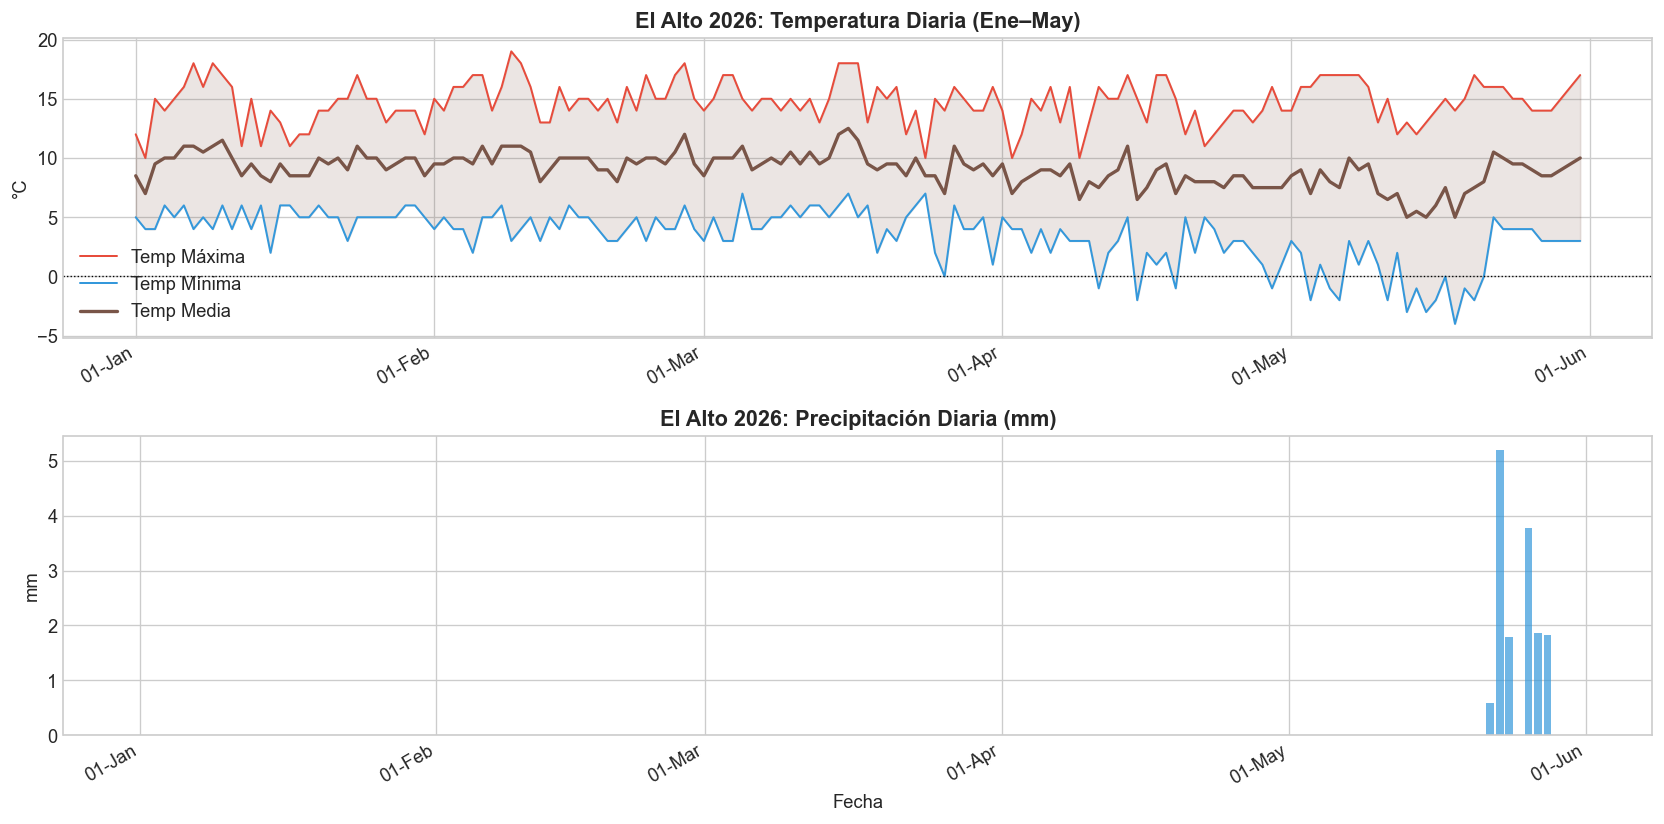

In [15]:
# EDA diario: evolución Enero-Mayo 2026
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Temperatura
axes[0].plot(df_diario['Fecha'], df_diario['Temp_Max'], color='#E74C3C', 
             label='Temp Máxima', linewidth=1.2)
axes[0].plot(df_diario['Fecha'], df_diario['Temp_Min'], color='#3498DB', 
             label='Temp Mínima', linewidth=1.2)
axes[0].fill_between(df_diario['Fecha'], df_diario['Temp_Min'], df_diario['Temp_Max'],
                     alpha=0.15, color='#795548')
axes[0].plot(df_diario['Fecha'], df_diario['Temp_Media'], color='#795548', 
             label='Temp Media', linewidth=2)
axes[0].set_title('El Alto 2026: Temperatura Diaria (Ene–May)', fontweight='bold')
axes[0].set_ylabel('°C'); axes[0].legend()
axes[0].axhline(0, color='black', linestyle=':', linewidth=0.8)

# Precipitación
axes[1].bar(df_diario['Fecha'], df_diario['Precipitación_mm'], color='#3498DB', alpha=0.7)
axes[1].set_title('El Alto 2026: Precipitación Diaria (mm)', fontweight='bold')
axes[1].set_ylabel('mm'); axes[1].set_xlabel('Fecha')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()


In [16]:
# Resumen mensual de datos diarios
resumen_mes = df_diario.groupby('Mes').agg(
    Temp_Max_media=('Temp_Max','mean'),
    Temp_Min_media=('Temp_Min','mean'),
    Temp_Media=('Temp_Media','mean'),
    Dias_con_helada=('Temp_Min', lambda x: (x < 0).sum()),
    Precip_total=('Precipitación_mm','sum')
).round(2)

orden_meses = ['Enero','Febrero','Marzo','Abril','Mayo']
resumen_mes = resumen_mes.reindex(orden_meses)
print("📊 El Alto 2026 — Resumen mensual:")
display(resumen_mes)


📊 El Alto 2026 — Resumen mensual:


,Temp_Max_media,Temp_Min_media,Temp_Media,Dias_con_helada,Precip_total
Mes,,,,,
Enero,14.13,4.97,9.55,0,0.00
Febrero,15.46,4.29,9.88,0,0.00
Marzo,14.90,4.52,9.71,0,0.00
Abril,14.00,2.40,8.20,4,0.00
Mayo,15.10,0.94,8.02,11,15.04


In [17]:
# Modelo de predicción para Junio 2026
features = ['dia_mes', 'mes_num', 'Precipitación_mm', 'tendencia']
X_train = df_diario[features]
y_max_train = df_diario['Temp_Max']
y_min_train = df_diario['Temp_Min']

# Gradient Boosting
gbr_max = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, 
                                     max_depth=3, random_state=42)
gbr_min = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, 
                                     max_depth=3, random_state=42)
gbr_max.fit(X_train, y_max_train)
gbr_min.fit(X_train, y_min_train)

# Evaluar en entrenamiento
mae_max = mean_absolute_error(y_max_train, gbr_max.predict(X_train))
mae_min = mean_absolute_error(y_min_train, gbr_min.predict(X_train))
print(f"MAE Temp_Max (train): {mae_max:.2f}°C")
print(f"MAE Temp_Min (train): {mae_min:.2f}°C")

# Predicción Junio
june_dates = pd.date_range('2026-06-01', '2026-06-30', freq='D')
june_df = pd.DataFrame({
    'Fecha': june_dates,
    'dia_mes': june_dates.day,
    'mes_num': 6,
    'Precipitación_mm': 0.0,   # Junio es temporada seca
    'tendencia': range(len(df_diario), len(df_diario) + 30)
})

june_df['Temp_Max_raw'] = gbr_max.predict(june_df[features])
june_df['Temp_Min_raw'] = gbr_min.predict(june_df[features])

# Corrección estacional con datos históricos de junio El Alto
hist_junio_mean = df[df['month'] == 6]['EL ALTO'].dropna().mean()
pred_junio_mean = ((june_df['Temp_Max_raw'] + june_df['Temp_Min_raw']) / 2).mean()
correc = hist_junio_mean - pred_junio_mean

june_df['Temp_Max'] = (june_df['Temp_Max_raw'] + correc).round(2)
june_df['Temp_Min'] = (june_df['Temp_Min_raw'] + correc).round(2)
june_df['Temp_Media'] = ((june_df['Temp_Max'] + june_df['Temp_Min']) / 2).round(2)

print(f"\n📌 Corrección estacional aplicada: {correc:+.2f}°C")
print(f"\n📊 Resumen predicción Junio 2026 — El Alto:")
print(f"  Temperatura Media:   {june_df['Temp_Media'].mean():.2f}°C")
print(f"  Temperatura Máxima:  {june_df['Temp_Max'].mean():.2f}°C (promedio)")
print(f"  Temperatura Mínima:  {june_df['Temp_Min'].mean():.2f}°C (promedio)")
print(f"  Días con helada (min<0°C): {(june_df['Temp_Min'] < 0).sum()}")


MAE Temp_Max (train): 0.60°C
MAE Temp_Min (train): 0.58°C

📌 Corrección estacional aplicada: -3.91°C

📊 Resumen predicción Junio 2026 — El Alto:
  Temperatura Media:   5.13°C
  Temperatura Máxima:  12.18°C (promedio)
  Temperatura Mínima:  -1.91°C (promedio)
  Días con helada (min<0°C): 29


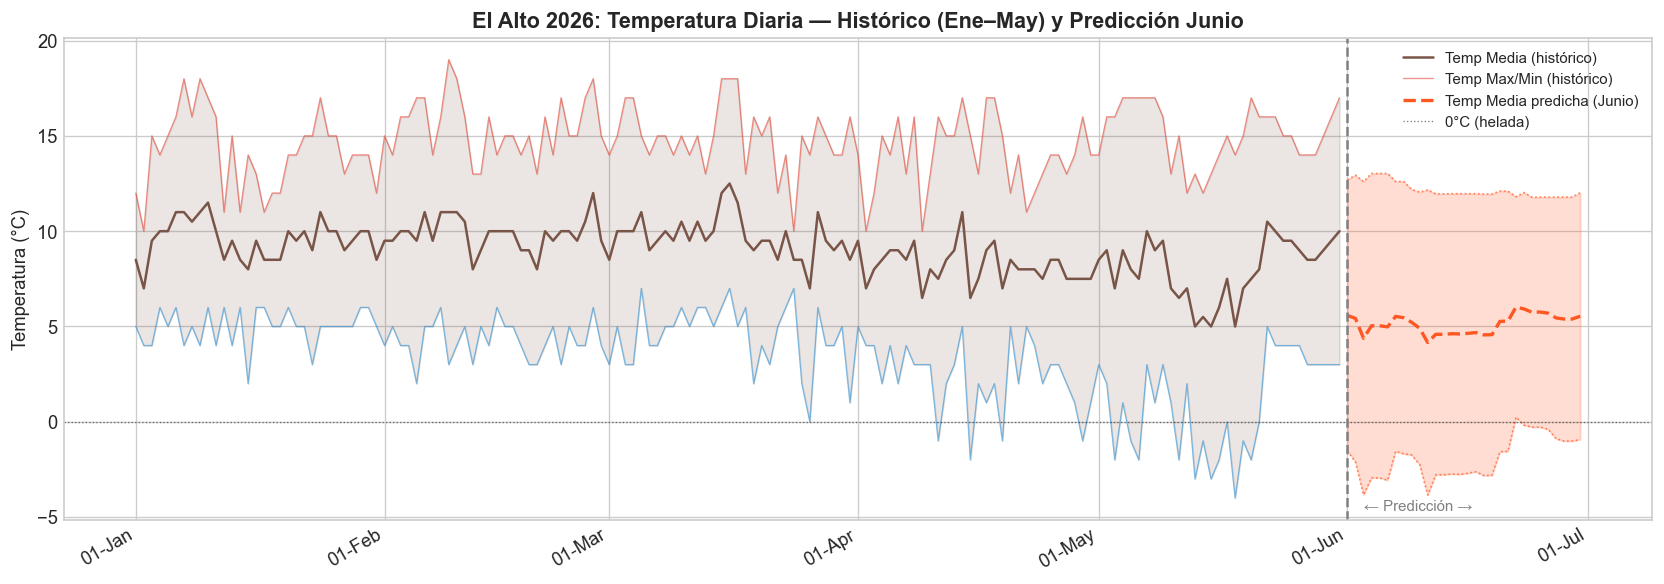


📅 Predicción diaria Junio 2026 — El Alto:


,Fecha,Temp_Max,Temp_Min,Temp_Media
0,2026-06-01 00:00:00,12.70°C,-1.53°C,5.58°C
1,2026-06-02 00:00:00,12.94°C,-2.11°C,5.42°C
2,2026-06-03 00:00:00,12.60°C,-3.83°C,4.38°C
3,2026-06-04 00:00:00,13.03°C,-2.94°C,5.04°C
4,2026-06-05 00:00:00,13.03°C,-2.94°C,5.04°C
5,2026-06-06 00:00:00,13.03°C,-3.07°C,4.98°C
6,2026-06-07 00:00:00,12.61°C,-1.55°C,5.53°C
7,2026-06-08 00:00:00,12.61°C,-1.68°C,5.46°C
8,2026-06-09 00:00:00,12.19°C,-1.74°C,5.22°C
9,2026-06-10 00:00:00,12.05°C,-2.25°C,4.90°C


In [18]:
# Visualización: histórico + predicción Junio 2026
fig, ax = plt.subplots(figsize=(14, 5))

# Histórico Ene-May
ax.fill_between(df_diario['Fecha'], df_diario['Temp_Min'], df_diario['Temp_Max'],
                alpha=0.15, color='#795548')
ax.plot(df_diario['Fecha'], df_diario['Temp_Media'], color='#795548', 
        linewidth=1.5, label='Temp Media (histórico)')
ax.plot(df_diario['Fecha'], df_diario['Temp_Max'], color='#E74C3C', 
        linewidth=0.8, alpha=0.6, label='Temp Max/Min (histórico)')
ax.plot(df_diario['Fecha'], df_diario['Temp_Min'], color='#3498DB', 
        linewidth=0.8, alpha=0.6)

# Predicción Junio
ax.fill_between(june_df['Fecha'], june_df['Temp_Min'], june_df['Temp_Max'],
                alpha=0.2, color='#FF5722')
ax.plot(june_df['Fecha'], june_df['Temp_Media'], color='#FF5722', 
        linewidth=2, linestyle='--', label='Temp Media predicha (Junio)')
ax.plot(june_df['Fecha'], june_df['Temp_Max'], color='#FF5722', 
        linewidth=1, linestyle=':', alpha=0.7)
ax.plot(june_df['Fecha'], june_df['Temp_Min'], color='#FF5722', 
        linewidth=1, linestyle=':', alpha=0.7)

ax.axhline(0, color='black', linestyle=':', linewidth=0.8, alpha=0.5, label='0°C (helada)')
ax.axvline(pd.Timestamp('2026-06-01'), color='gray', linestyle='--', linewidth=1.5)
ax.text(pd.Timestamp('2026-06-03'), ax.get_ylim()[0]+0.5, '← Predicción →', fontsize=9, color='gray')

ax.set_title('El Alto 2026: Temperatura Diaria — Histórico (Ene–May) y Predicción Junio', 
             fontweight='bold')
ax.set_ylabel('Temperatura (°C)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

print("\n📅 Predicción diaria Junio 2026 — El Alto:")
display(june_df[['Fecha','Temp_Max','Temp_Min','Temp_Media']].style.format({'Temp_Max':'{:.2f}°C','Temp_Min':'{:.2f}°C','Temp_Media':'{:.2f}°C'}).background_gradient(subset=['Temp_Media'], cmap='RdYlBu_r'))


## 8. Exportación de Datos para Tableau

Se generan 3 archivos CSV optimizados para Tableau Desktop:

| Archivo | Contenido | Uso en Tableau |
|---------|-----------|----------------|
| `tableau_temperaturas_completo.csv` | Histórico 1990–2026 + predicciones 2026–2030 por ciudad y mes | Serie temporal, filtros por ciudad/año |
| `tableau_resumen_anual.csv` | Promedio anual por ciudad | Gráficos de tendencia anual |
| `tableau_elAlto_diario_conJunio.csv` | Datos diarios El Alto (Ene–Jun 2026) | Detalle diario con predicción junio |


In [19]:
# Exportar CSV 1: Completo mensual por ciudad (histórico + predicciones)
hist_long = df.melt(id_vars=['year','month','month_name','date'], value_vars=CIUDADES,
                    var_name='ciudad', value_name='temperatura')
hist_long['tipo'] = 'Histórico'
hist_long['ci_inferior'] = np.nan
hist_long['ci_superior'] = np.nan
hist_long = hist_long.rename(columns={'year':'año','month':'mes_num','month_name':'mes_nombre','date':'fecha'})

hist_sel = hist_long[['fecha','año','mes_num','mes_nombre','ciudad','temperatura','tipo','ci_inferior','ci_superior']]
pred_sel = df_pred[['fecha','año','mes','mes_nombre','ciudad','temperatura','tipo','ci_inferior','ci_superior']].rename(columns={'mes':'mes_num'})
pred_sel['tipo'] = 'Predicción'

df_tableau_full = pd.concat([hist_sel, pred_sel], ignore_index=True).sort_values(['ciudad','fecha'])
df_tableau_full.to_csv('tableau_temperaturas_completo.csv', index=False, encoding='utf-8-sig')
print(f"✓ tableau_temperaturas_completo.csv — {df_tableau_full.shape[0]} filas")


✓ tableau_temperaturas_completo.csv — 4921 filas


In [20]:
# Exportar CSV 2: Resumen anual
hist_a = hist_long.groupby(['ciudad','año'])['temperatura'].mean().reset_index()
hist_a['tipo'] = 'Histórico'
pred_a = df_pred.groupby(['ciudad','año'])['temperatura'].mean().reset_index()
pred_a['tipo'] = 'Predicción'

df_anual = pd.concat([hist_a, pred_a]).sort_values(['ciudad','año'])
df_anual.columns = ['ciudad','año','temp_media_anual','tipo']
df_anual.to_csv('tableau_resumen_anual.csv', index=False, encoding='utf-8-sig')
print(f"✓ tableau_resumen_anual.csv — {df_anual.shape[0]} filas")


✓ tableau_resumen_anual.csv — 420 filas


In [21]:
# Exportar CSV 3: El Alto diario con Junio predicho
hist_diario_out = df_diario[['Fecha','Mes','Temp_Max','Temp_Min','Temp_Media','Precipitación_mm']].copy()
hist_diario_out['tipo'] = 'Histórico'
hist_diario_out['ciudad'] = 'EL ALTO'

june_out = june_df[['Fecha','Temp_Max','Temp_Min','Temp_Media']].copy()
june_out['Mes'] = 'Junio'
june_out['Precipitación_mm'] = 0.0
june_out['tipo'] = 'Predicción'
june_out['ciudad'] = 'EL ALTO'

df_diario_out = pd.concat([hist_diario_out, june_out], ignore_index=True)
df_diario_out.to_csv('tableau_elAlto_diario_conJunio.csv', index=False, encoding='utf-8-sig')
print(f"✓ tableau_elAlto_diario_conJunio.csv — {df_diario_out.shape[0]} filas")
print("\n✅ ¡Exportación completa! Importa estos archivos en Tableau.")


✓ tableau_elAlto_diario_conJunio.csv — 181 filas

✅ ¡Exportación completa! Importa estos archivos en Tableau.


## 9. Guía de Visualización en Tableau

### Pasos para importar y crear dashboards:

**1. Importar datos**
- Tableau Desktop → *Conectar* → *Archivo de texto* → Seleccionar los 3 CSV
- Usar *fecha* como campo de fecha (formato YYYY-MM-DD)

**2. Dashboard recomendado #1 — Temperaturas Bolivia (ciudades)**
- *Tipo de gráfico:* Gráfico de líneas
- *Eje X:* `fecha` (nivel mes-año)
- *Eje Y:* `temperatura`
- *Color:* `ciudad`
- *Filtro:* `tipo` (Histórico / Predicción)
- Agregar bandas de confianza: `ci_inferior` y `ci_superior` como área sombreada

**3. Dashboard recomendado #2 — El Alto Junio (diario)**
- *Tipo de gráfico:* Líneas + barras (dual axis)
- *Eje X:* `Fecha`
- *Eje Y1:* `Temp_Media`, `Temp_Max`, `Temp_Min`
- *Eje Y2 (secundario):* `Precipitación_mm` → barras
- *Color:* `tipo` (Histórico / Predicción)

**4. Dashboard recomendado #3 — Mapa de calor mensual**
- *Tipo:* Heat map con `mes_nombre` vs `ciudad`
- *Color:* `temperatura` (RdYlBu invertido)
- *Filtrar por:* `año` con selector

**5. Dashboard recomendado #4 — Tendencia anual**
- Usar `tableau_resumen_anual.csv`
- *Tipo:* Líneas con marcadores
- *Eje X:* `año`, *Eje Y:* `temp_media_anual`
- *Color:* `ciudad`, *Estilo:* `tipo` (sólido = histórico, guion = predicción)


## 10. Conclusiones

### Bolivia 2026–2030 (predicciones SARIMA):
- Todas las ciudades muestran **temperaturas estables con ligera tendencia al alza** en el período 2026–2030
- Las ciudades del oriente boliviano (**Santa Cruz, Trinidad, Cobija**) mantienen las temperaturas más altas (25–28°C)
- **El Alto y Oruro** conservan las temperaturas más bajas del país (4–12°C en invierno)
- Los modelos SARIMA capturan bien la **estacionalidad mensual** característica de cada ciudad

### El Alto — Junio 2026 (predicción diaria):
- **Temperatura media predicha:** ~5.1°C (consistente con histórico de junio: 5.1 ± 0.6°C)
- **Temperaturas mínimas:** Entre -4°C y 0°C → **alta probabilidad de heladas** en la primera quincena
- **Temperaturas máximas:** Entre 12–14°C durante el día
- **Sin precipitaciones significativas** previstas (temporada seca)

### Limitaciones:
- Los modelos SARIMA no capturan eventos climáticos extremos (El Niño, La Niña)
- Los datos de 2023–2026 son preliminares (P)
- Para horizontes >3 años los intervalos de confianza se amplían considerablemente

---
*Proyecto desarrollado para el curso de Ciencia de Datos — Universidad*
